# Week 4: OLS Demand Model

In [1]:
import numpy as np
import pandas as pd
pd.options.mode.chained_assignment = None 
import pickle

import os
from importlib import reload

import matplotlib.pyplot as plt
import matplotlib 
# import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')
from matplotlib.ticker import MultipleLocator

### load competition data and show some stats

In [2]:
df_comp_details = pd.read_csv('duopoly_competition_details.csv')
df_comp_details.fillna(0, inplace=True)

df_comp_details['revenue'] = df_comp_details['price'] * df_comp_details['demand']

df_comp_details.head(3)

,competition_id,selling_season,selling_period,competitor_id,price_competitor,price,demand,competitor_has_capacity,calculation_duration,errors,revenue
0,3C4dDe,1,1,LoutishMacaque,56.1,56.3,0,True,0.004,0.0,0.0
1,3C4dDe,1,2,LoutishMacaque,2.0,56.3,0,True,0.004,0.0,0.0
2,3C4dDe,1,3,LoutishMacaque,3.0,56.3,0,True,0.003,0.0,0.0


In [3]:
df_comp_details['unique_selling_season_key'] = df_comp_details.apply(lambda r:
                                "%s_%s" % (r.competition_id,r.selling_season), axis=1)

In [4]:
dfx_rev = df_comp_details.groupby('unique_selling_season_key').agg({
    'revenue' : 'sum'
}).reset_index()
dfx_rev.head(3)

,unique_selling_season_key,revenue
0,3C4dDe_1,115.9
1,3C4dDe_10,300.8
2,3C4dDe_100,337.3


# Let us build our own demand model based on the competition data.

## => f(price, competitor_price) = demand

## idea:
- split selling_season into sub-intervals where we assume a constant demand model
    - e.g. selling period [1,20] assumed to have almost constant demand
- estimate the demand model per competition
- train on first 50 selling_seasons and evaluate on the last 50

3yUFj3


<Axes: >

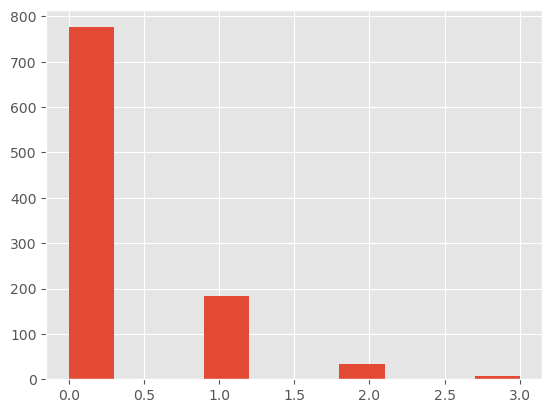

In [5]:
comp = df_comp_details.competition_id.unique()[1]
print(comp)

# filter on first competion_id
df = df_comp_details[df_comp_details.competition_id==comp ]

# concentrate on selling period in [1,20]
df = df[df.selling_period <= 20 ]

df_train = df[df.selling_season<=50]
df_test = df[df.selling_season>50]

df_train.demand.hist()

<Axes: >

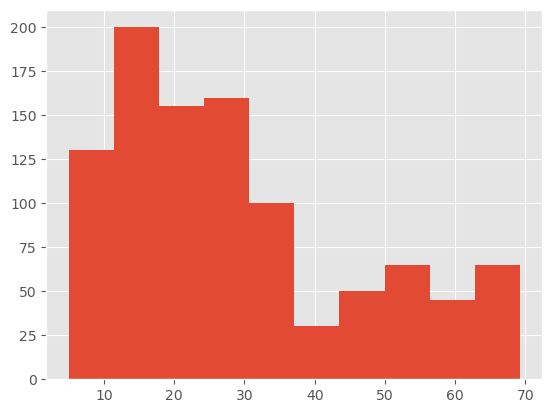

In [6]:
# df_train.head(35)
# df_train.demand.hist()
df_train.price.hist()

<Axes: >

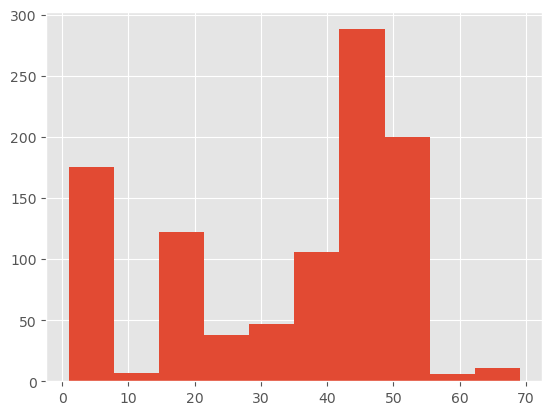

In [7]:
df_train.price_competitor.hist()

## (a) fit OLS model

In [8]:
import statsmodels.api as sm
# https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html

y = CODE HERE
X = CODE HERE
X['intercept'] = 1


mod = sm.OLS(y, X)
# mod = sm.regression.quantile_regression.QuantReg(y,X)

res = mod.fit()

print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 demand   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     70.62
Date:                Tue, 28 Oct 2025   Prob (F-statistic):           2.07e-29
Time:                        00:28:06   Log-Likelihood:                -759.89
No. Observations:                1000   AIC:                             1526.
Df Residuals:                     997   BIC:                             1540.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
price               -0.0100      0.001  

## (b) predict demand based on function for
- own price = 30
- competitor price = 50

In [9]:
mod.predict(res.params, CODE HERE )

np.float64(0.38279312992154885)

## (c) simulate demand, our prices in [1,100] and competitor_price = 50

In [11]:
def est_demand(price, comp_price, para = res.params):
    demand = CODE HERE
    demand = max(0,demand)
    return demand

df_sim = pd.DataFrame(columns = ['price','demand','rev'])
for p in np.arange(1,100,1):
    demand = CODE HERE
    rev = CODE HERE
    df_sim.loc[len(df_sim)] = [p,demand,rev]

    
df_sim.head()

,price,demand,rev
0,1.0,0.968088,0.968088
1,2.0,0.958085,1.916170
2,3.0,0.948082,2.844245
3,4.0,0.938078,3.752313
4,5.0,0.928075,4.640376


#### plot demand and revenue curve

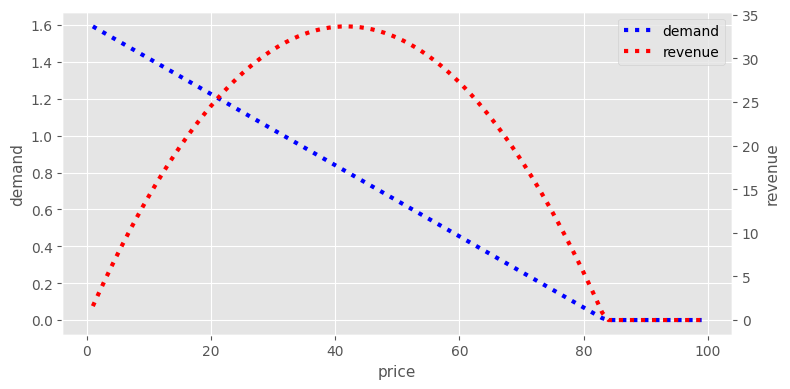

In [22]:
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df_sim['price'], df_sim['demand'], color='b', 
        linestyle='dotted', linewidth=3, label='demand')

ax_2 = ax.twinx()
ax_2.grid(False)
ax_2.plot(df_sim['price'], df_sim['rev'], color='r', 
        linestyle='dotted', linewidth=3, label='revenue')

ax_2.tick_params(axis="both", labelsize=10)
ax.tick_params(axis="both", labelsize=10)

# legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax_2.get_legend_handles_labels()
ax_2.legend(lines + lines2, labels + labels2, loc=0)

ax.set_xlabel('price', size=11)
ax.set_ylabel("demand" , size=11)
ax_2.set_ylabel("revenue" , size=11)

ax.grid(True)
fig.tight_layout()

plt.show()

## (d) compute estimated demand in computation details

In [12]:
df_eval = df_test[['unique_selling_season_key','selling_season','selling_period','price_competitor', 'price', 'demand']]

df_eval.head(5)

,unique_selling_season_key,selling_season,selling_period,price_competitor,price,demand
15000,3yUFj3_51,51,1,57.5,56.4,0
15001,3yUFj3_51,51,2,42.0,56.4,1
15002,3yUFj3_51,51,3,42.0,56.4,0
15003,3yUFj3_51,51,4,42.0,56.4,0
15004,3yUFj3_51,51,5,42.0,56.4,0


In [13]:
# estimate demand
df_eval['est_demand'] = df_eval.apply(lambda r:
            CODE HERE,
            axis=1)

# compute error metrics (error = predicted - actual)
df_eval['est_error'] = CODE HERE
df_eval['abs_est_error'] = df_eval['est_error'].abs()

df_eval.head(5)

,unique_selling_season_key,selling_season,selling_period,price_competitor,price,demand,est_demand,est_error,abs_est_error
15000,3yUFj3_51,51,1,57.5,56.4,0,0.174058,0.174058,0.174058
15001,3yUFj3_51,51,2,42.0,56.4,1,0.059668,-0.940332,0.940332
15002,3yUFj3_51,51,3,42.0,56.4,0,0.059668,0.059668,0.059668
15003,3yUFj3_51,51,4,42.0,56.4,0,0.059668,0.059668,0.059668
15004,3yUFj3_51,51,5,42.0,56.4,0,0.059668,0.059668,0.059668


In [14]:
df_eval[['demand', 'est_demand', 'est_error', 'abs_est_error']].describe()

,demand,est_demand,est_error,abs_est_error
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.354000,0.341766,-0.012234,0.462066
std,0.636466,0.162889,0.613676,0.403769
min,0.000000,0.000000,-3.537160,0.000000
25%,0.000000,0.255108,-0.491438,0.261940
50%,0.000000,0.392818,0.220608,0.423695
75%,1.000000,0.462840,0.409914,0.540268
max,4.000000,0.643521,0.643521,3.537160


### plot the actual demand vs. estimated demand for one test selling season

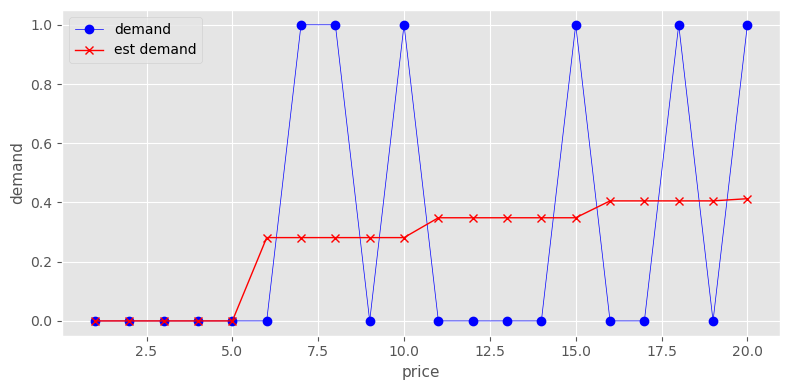

In [15]:
dfe = df_eval[df_eval.selling_season==60]

fig, ax = plt.subplots(figsize=(8,4))

ax.plot(dfe['selling_period'], dfe['demand'], color='b', 
        linestyle='-', marker='o', linewidth=0.5, markersize=6, label='demand')

ax.plot(dfe['selling_period'], dfe['est_demand'], color='r', 
        linestyle='-', marker='x', linewidth=1, markersize=6, label='est demand')

ax.legend( loc=0)

ax.set_xlabel('price', size=11)
ax.set_ylabel("demand" , size=11)

ax.grid(True)
fig.tight_layout()

plt.show()

# next tasks:
## (1) estimate five demand models covering the 100 period selling_season
## (2) estimate demand models for every simulation_id 
## (3) implement the demand model in your own simulation (last week simulation notebook)
## (4) implement the demand model estimation & next price optimization in your pricing algorithm